In [ ]:
Content
1. Basics
2. HLD Components
3. Architecture
4. Other Compoenets
    - Virtualization
    - Containerization
5. How to Implement HLD
6. Examples
    - Netflix

# 1. Basics

In [ ]:
Good Design should have:
1. Scalability: 
    - Improve Performance: Caching, CDN
        - Caching
            - Server Cache, 
    
2. Maintainablitlity: Future developers can understand & Improve system.
3. Efficiency: Best use of resources
4. Reliability: Planning for failures
    - System works correctly and consistently
    4.1 Fault Tolerance: How our system handles unexpected failures
    4.2 Redundancy: Backup system, if primary goes down.

# Service Levels Object/ Agreements
1. SLO: Service Level Objects:
    - For ex: API should have 300 ms latency and 99.9% uptime.
2. SLA: Service Level Agreements
    - Minimum level of service committing to users, If not achieved we may have to provide compansations.

        

# 2. HLD Components

1. API Gateway
 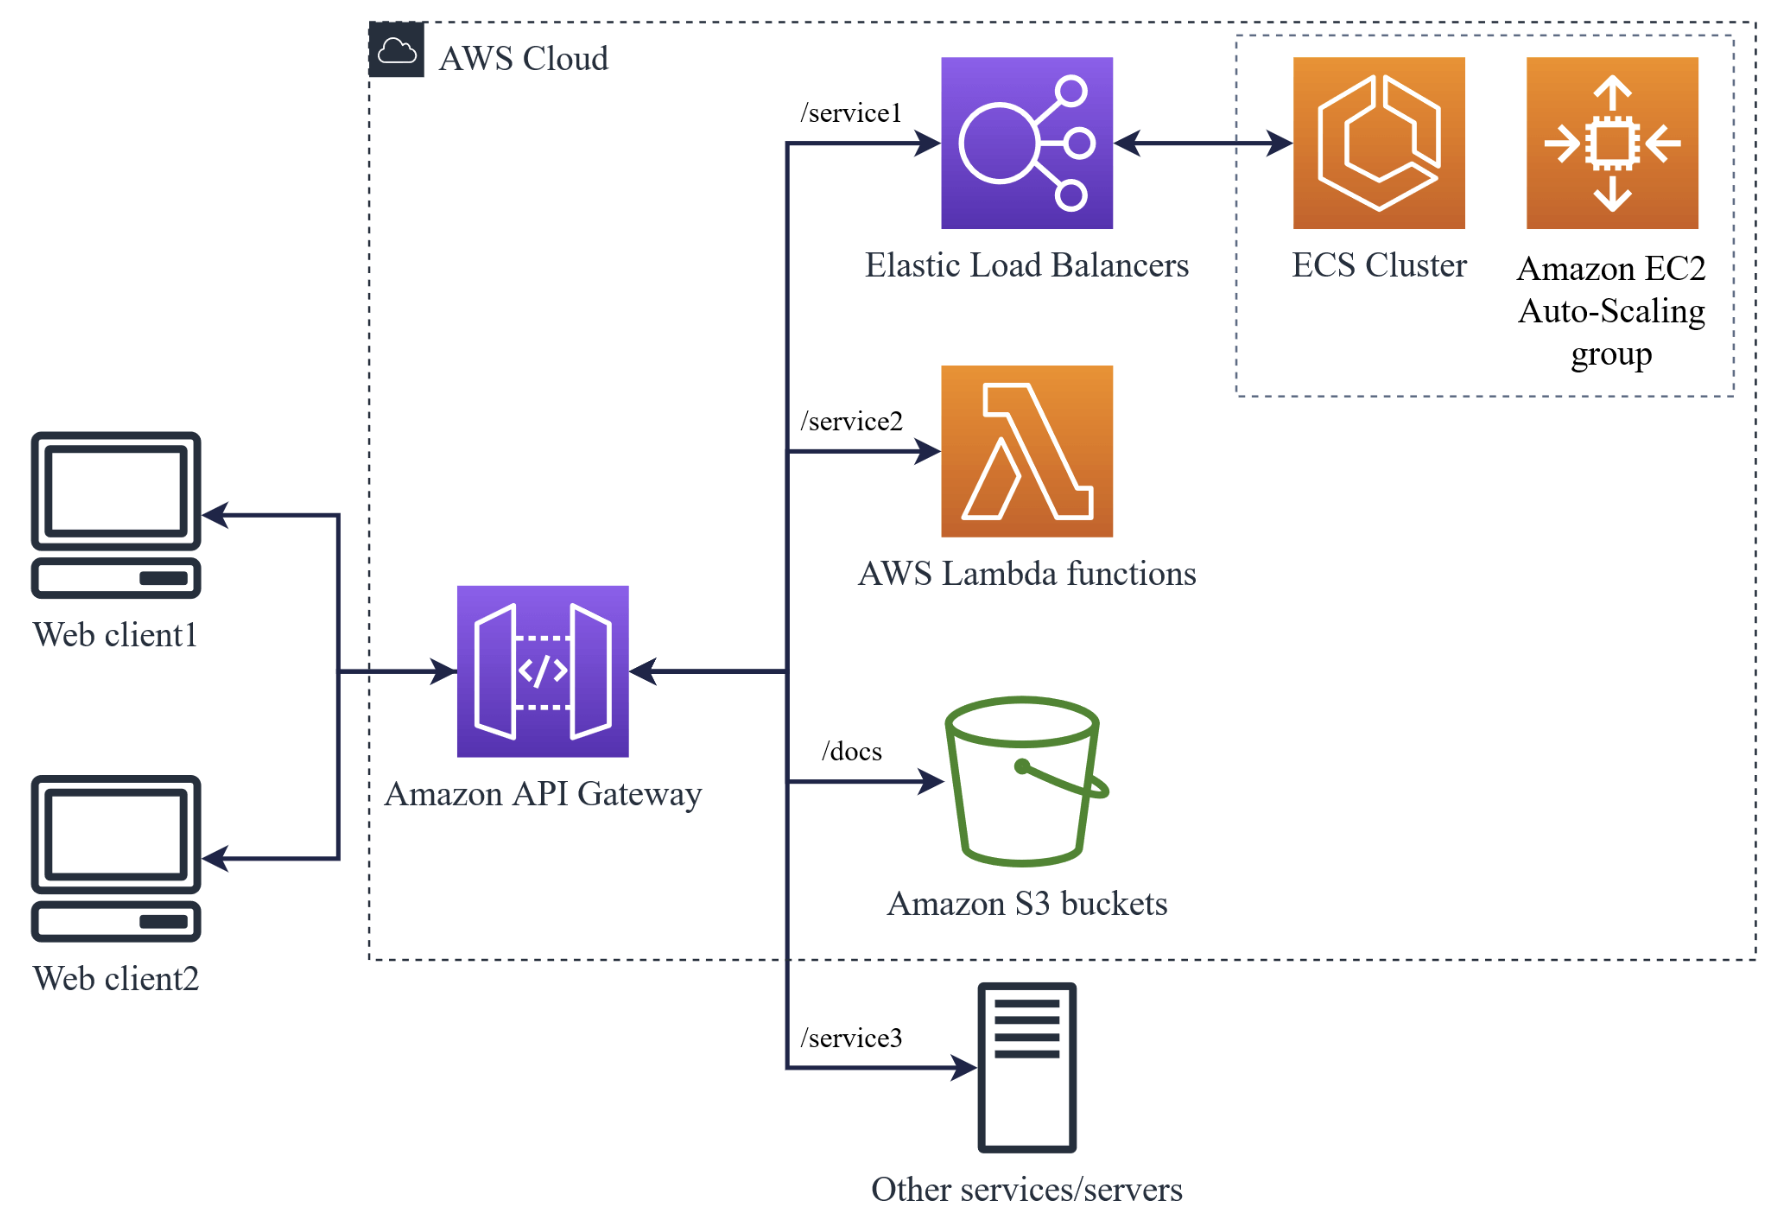

----------------------------------------
2. Redis Cache
 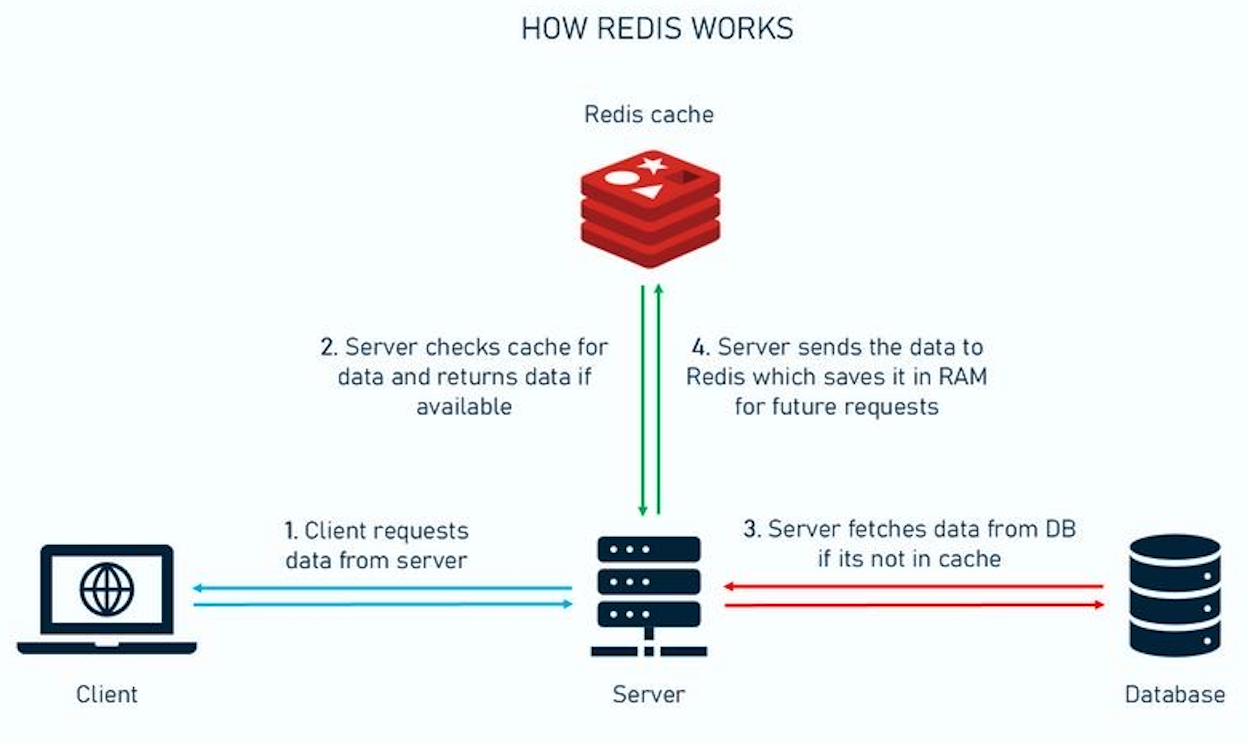

# System Design Components
https://app.eraser.io/workspace/OEM45LzAjaosgx68YhaO?origin=share

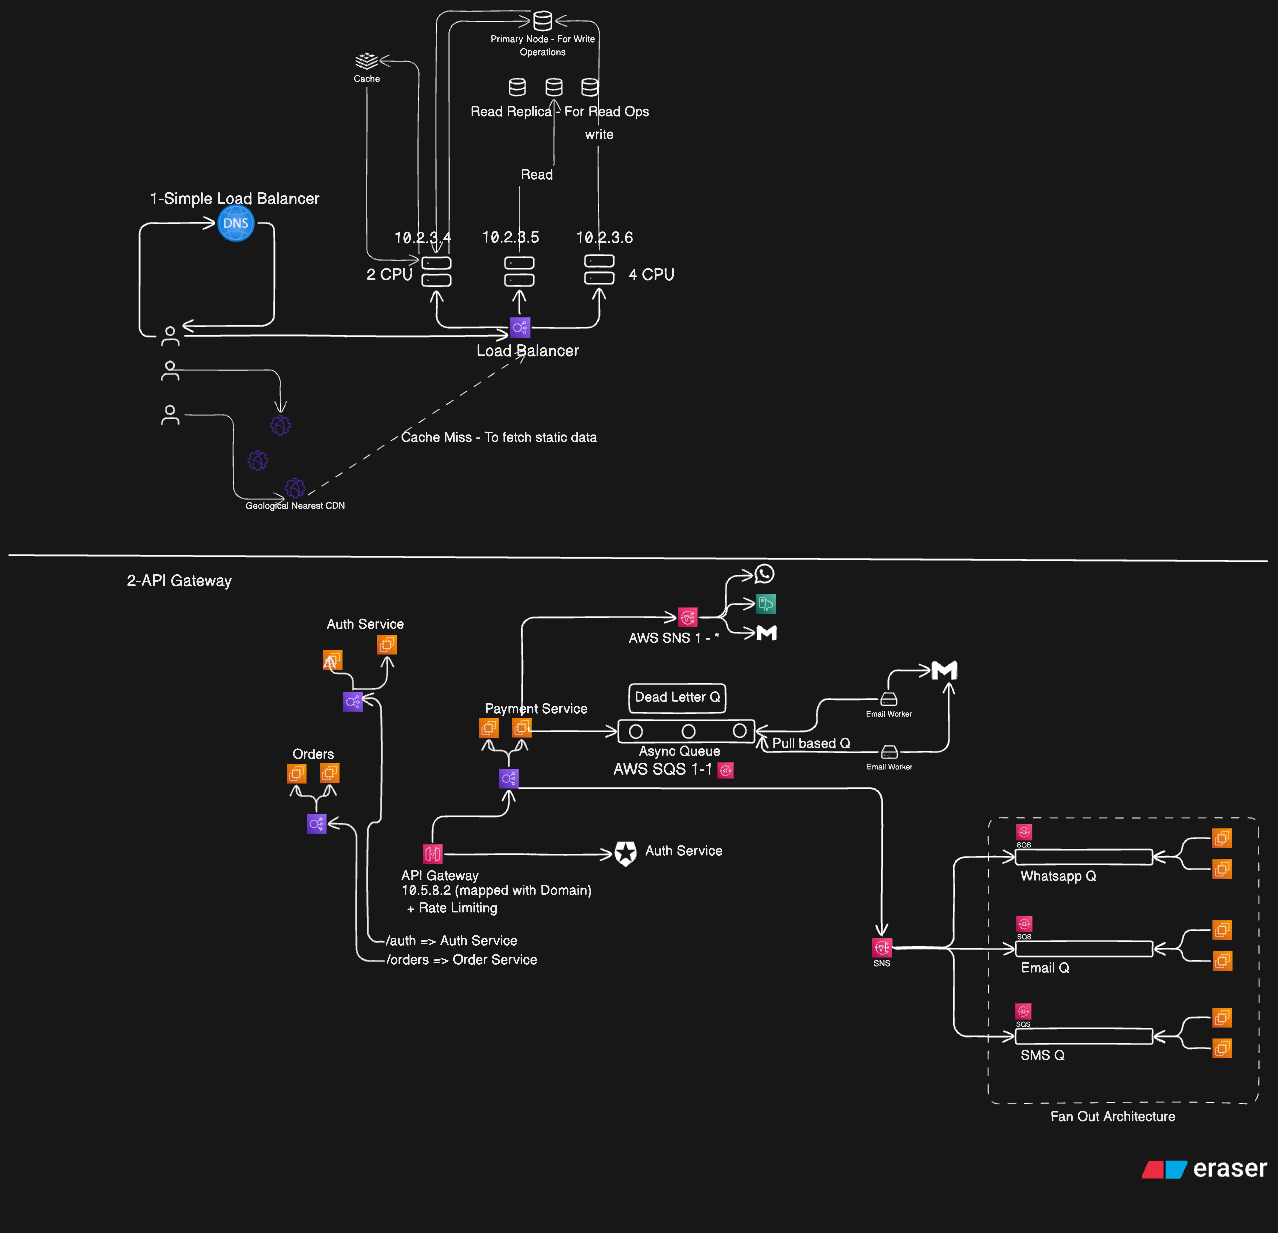

In [ ]:
# Redis Cache
Client Request → Load Balancer → App Server
                     → Check Cache (Redis)
                         → HIT → return data ✅
                         → MISS → Query Read Replica → Update Cache → return


# CDN - Anycast
- Anycast: Anycast is a networking technique where multiple servers share the same IP address, and the network automatically routes the user to the nearest (or best) server.
- Same IP, multiple locations → user gets routed to closest CDN server.

# CDN Flow
    a. User → CDN Edge (nearest location via Anycast)
    b. Cache Hit: CDN → returns response directly
    c. Cache Miss: CDN → Origin (your system) via Load Balancer
    

# 3. Architecture

In [ ]:
1. Fan Out Architecture
    a. The main service publish a message in Amazon SNS (pub/sub mode). For example Notification to SMS, Email, Whatsapp
    b. Then, SNS put messages in each of SQS.
    c. Then, SQS will process their messages independently.

Pub/Sub Fan Out Architecture
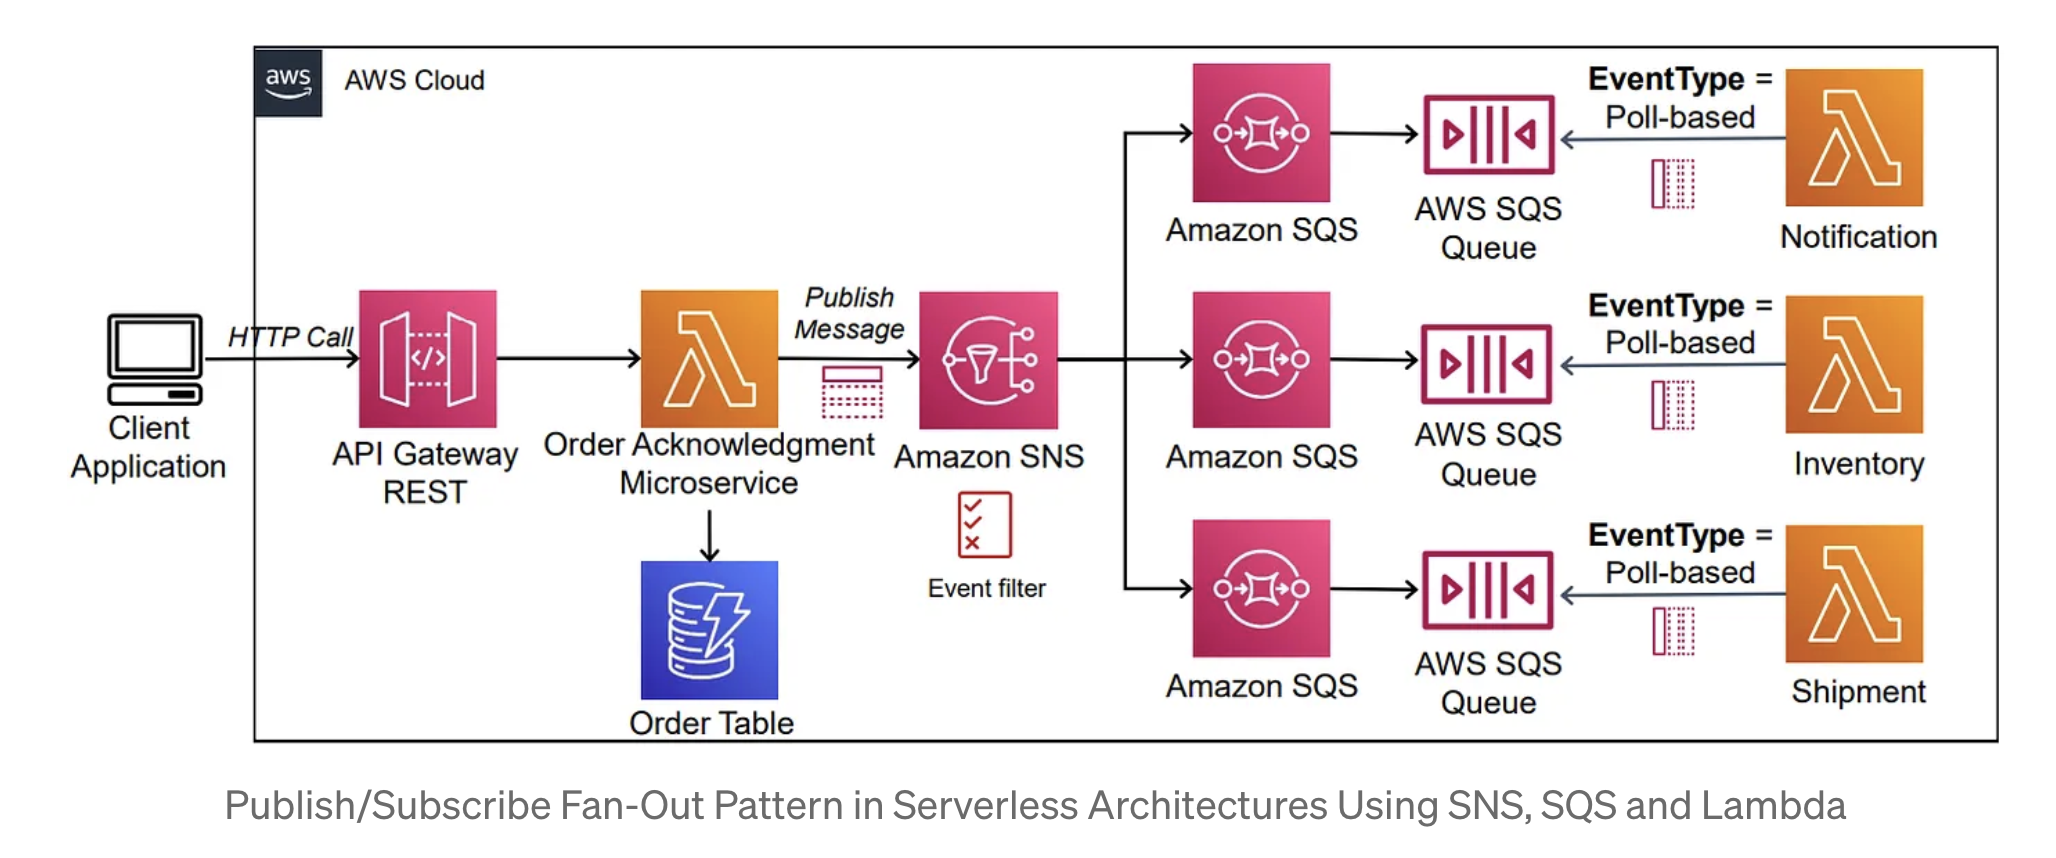

# 4. Other Compoenets

In [ ]:
# Virtualization
    - Virtualization runs multiple OS instances using a hypervisor
    - Running an VM machine with its own OS on another machine. For example, Run VMware with ubuntu on local windows laptop.
    - VM -  OS, your code packages and your code.
        
# Containerization
    - It is like Lightweight VM without OS.
    - Running applications in isolated environments that share the same OS kernel.
    - All containers share the same OS kernel. (Physical machine OS kernel) 
+--------------------------------------------------+
|                Physical Machine                  |
|  (CPU, Memory, Disk, Network)                   |
+--------------------------------------------------+
                     │
                     ▼
+--------------------------------------------------+
|                  Host OS                         |
|        (Linux Kernel - shared by all)           |
+--------------------------------------------------+
                     │
                     ▼
+--------------------------------------------------+
|            Container Runtime / Engine            |
|         (Docker / containerd / CRI-O)           |
+--------------------------------------------------+
        │                 │                │
        ▼                 ▼                ▼
+----------------+  +----------------+  +----------------+
|  Container 1   |  |  Container 2   |  |  Container 3   |
|----------------|  |----------------|  |----------------|
| App + Binaries |  | App + Binaries |  | App + Binaries |
| Libraries      |  | Libraries      |  | Libraries      |
| Dependencies   |  | Dependencies   |  | Dependencies   |
| (Isolated)     |  | (Isolated)     |  | (Isolated)     |
+----------------+  +----------------+  +----------------+

⚠️ Note:
- All containers SHARE the same OS kernel
- Isolation via namespaces + cgroups

# Kubernatics
# Container orchestration
    - Problem: On each physical sever, multiple containers are created/ destroyed and require management.
    -  So, The brain to manage all the containers is called Kubernatics.
    - Kubernetes (K8s) is a system that deploys, scales, and manages containers automatically (usually containers built with Docker).
    - Features:
        - Auto-Scaling (Horizontal)
        -  Self-healing
        -  Load Balancing

# 5. How to Implement HLD

In [ ]:
1. Requirements
    - First, we have to understand the traffic patterns.

In [ ]:
# Problems:
    - If traffic is increasing slowly, then it is easy to hanle. Sudden spike in traffic are difficult to handle.

In [ ]:
# 

# 6. Examples

In [ ]:
1. Netflix
 - In Netflix, as soon as a new movie is uploaded, there is a significant spike in trafic. Auto-scaling might not be able to handle that properly.
 - In this case, we are already know about the future spike in traffics, we would increase the server capacity, one day before (before the new movie upload).
 - In youtube also, It might try to predict the next hr traffic, depends on who uploads the movie.

2. Hotstar
 - If there very sudden spike and down in traffic, Auto-scaling would not work here. Here, you have to manually keep the server running.